In [1]:
import torch
print(f"¿PyTorch detecta CUDA?: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("PyTorch sigue en modo CPU. Verifica los drivers de NVIDIA.")

¿PyTorch detecta CUDA?: True
GPU detectada: NVIDIA GeForce RTX 4070 Ti


In [1]:
# TÍTULO: Entrenamiento Comparativo - YOLOv8 vs Custom CNN (OCR)
# OBJETIVO: Entrenar y comparar dos arquitecturas para clasificación de caracteres.

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from ultralytics import YOLO
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from datetime import datetime
from tqdm.notebook import tqdm
from PIL import Image

# --- CONFIGURACIÓN DE HARDWARE ---
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"GPU Activa: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device('cpu')
    print("ALERTA: Usando CPU. El entrenamiento será lento.")

# --- RUTAS ---
# Dataset generado en el paso anterior
DATASET_DIR = '../../datasets/03_caracteres' 
# Carpeta para guardar ambos modelos
PROJECT_DIR = '../../models/03_caracteres'
os.makedirs(PROJECT_DIR, exist_ok=True)

# Parámetros Globales
IMG_SIZE = 64      # Tamaño de entrada (caracteres son pequeños)
BATCH_SIZE = 64
EPOCHS = 50        # Suficiente para caracteres simples
NUM_CLASSES = 33   # A-Z (26) + 0-9 (10) - 3 (caracteres especiales)

print("Entorno listo.")

PyTorch Version: 2.5.1+cu121
GPU Activa: NVIDIA GeForce RTX 4070 Ti
Entorno listo.


In [2]:
import cv2
import numpy as np

def preprocesar_entrenamiento(img_pil):
    # Convertir a array de numpy
    img = np.array(img_pil)
    gris = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Binarización Adaptativa (mismo que en tu pipeline actual)
    binaria = cv2.adaptiveThreshold(
        gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 11, 2
    )
    
    # Dilatación leve para engrosar trazos (ayuda a la "pata" de la R)
    kernel = np.ones((2,2), np.uint8)
    binaria = cv2.dilate(binaria, kernel, iterations=1)
    
    # Redimensionar a 64x64
    binaria = cv2.resize(binaria, (64, 64), interpolation=cv2.INTER_AREA)
    
    # Regresar a formato PIL para las transformaciones de PyTorch
    return Image.fromarray(cv2.cvtColor(binaria, cv2.COLOR_GRAY2RGB))

In [3]:
# Transformaciones para la CNN Custom (Normalización estándar)
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(preprocesar_entrenamiento), 
    transforms.RandomRotation(5),                 
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalización estándar
])

# Cargar Datasets usando ImageFolder (detecta carpetas A, B, C...)
train_dir = os.path.join(DATASET_DIR, 'train')
val_dir = os.path.join(DATASET_DIR, 'val')

# Verificación de seguridad
if not os.path.exists(train_dir):
    raise FileNotFoundError(f"No se encuentra el dataset en {train_dir}")

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Guardar nombres de clases
CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Datos cargados:")
print(f"   - Clases ({NUM_CLASSES}): {CLASS_NAMES[:]}")
print(f"   - Train images: {len(train_dataset)}")
print(f"   - Val images:   {len(val_dataset)}")

Datos cargados:
   - Clases (33): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
   - Train images: 150677
   - Val images:   37685


In [ ]:
print("\Entrenando YOLOv8 Nano (Classifier)...")

# Nombre del experimento YOLO
run_name_yolo = f"{datetime.now().strftime('%Y%m%d')}_ocr_yolo_v8n_33"

# Cargar modelo
model_yolo = YOLO('yolov8n-cls.pt')

# Entrenar
start_time = time.time()
results_yolo = model_yolo.train(
    data=DATASET_DIR,
    project=PROJECT_DIR,
    name=run_name_yolo,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    pretrained=True,
    device=0 if torch.cuda.is_available() else 'cpu',
    verbose=True
)
yolo_train_time = time.time() - start_time

print(f"YOLO entrenamiento completado en {yolo_train_time:.2f} segundos.")

\Entrenando YOLOv8 Nano (Classifier)...
Ultralytics 8.4.46 🚀 Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11854MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/03_caracteres, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=20260503_ocr_yolo_v8n, nbs=64, nms=False, opse

In [23]:
print("\Entrenando YOLOv8 Nano (Classifier)...")

# Nombre del experimento YOLO
run_name_yolo = f"{datetime.now().strftime('%Y%m%d')}_ocr_yolo_v8n_33"

# Cargar modelo
model_yolo = YOLO('yolov8n-cls.pt')

# Entrenar
start_time = time.time()
results_yolo = model_yolo.train(
    data=DATASET_DIR,
    project=PROJECT_DIR,
    name=run_name_yolo,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    pretrained=True,
    device=0 if torch.cuda.is_available() else 'cpu',
    verbose=True
)
yolo_train_time = time.time() - start_time

print(f"YOLO entrenamiento completado en {yolo_train_time:.2f} segundos.")

\Entrenando YOLOv8 Nano (Classifier)...
New https://pypi.org/project/ultralytics/8.4.47 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11854MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/03_caracteres, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, mul

/home/roberto/miniconda3/envs/yolov8/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1299: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/roberto/miniconda3/envs/yolov8/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1301: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(tr

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 94.1±39.6 MB/s, size: 1.7 KB)
train: Scanning /home/roberto/moca_proyecto/datasets/03_caracteres/train... 150677 images, 0 corrupt: 100% ━━━━━━━━━━━━ 150677/150677 7.8Kit/s 19.2s<0.0s
train: New cache created: /home/roberto/moca_proyecto/datasets/03_caracteres/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 78.3±57.7 MB/s, size: 1.8 KB)
val: Scanning /home/roberto/moca_proyecto/datasets/03_caracteres/val... 37685 images, 0 corrupt: 100% ━━━━━━━━━━━━ 37685/37685 83.4Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 26 weight(decay=0.0), 27 weight(decay=0.0005), 27 bias(decay=0.0)
Image sizes 64 train, 64 val
Using 8 dataloader workers
Logging results to /home/roberto/moca_proyecto/models/03_caracteres/20260506_ocr_yolo_v8n_33
Starting

/home/roberto/miniconda3/envs/yolov8/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50     0.371G      1.964         21         64: 100% ━━━━━━━━━━━━ 2355/2355 57.4it/s 41.0s<0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 295/295 144.4it/s 2.0s0.1s
                   all      0.822      0.988

      Epoch    GPU_mem       loss  Instances       Size
       2/50     0.371G     0.9986         64         64: 0% ──────────── 11/2355 27.7it/s 0.2s<1:25

...

      48/50     0.371G     0.1682         21         64: 100% ━━━━━━━━━━━━ 2355/2355 58.6it/s 40.2s<0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 295/295 147.2it/s 2.0s0.0s
                   all      0.974          1

      Epoch    GPU_mem       loss  Instances       Size
      49/50     0.371G     0.1389         64         64: 0% ──────────── 7/2355 18.2it/s 0.1s<2:09

/home/roberto/miniconda3/envs/yolov8/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50     0.371G     0.1614         21         64: 100% ━━━━━━━━━━━━ 2355/2355 57.9it/s 40.7s<0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 295/295 144.9it/s 2.0s0.1s
                   all      0.974          1

      Epoch    GPU_mem       loss  Instances       Size
      50/50     0.371G      0.133         64         64: 0% ──────────── 6/2355 15.7it/s 0.1s<2:29

/home/roberto/miniconda3/envs/yolov8/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50     0.371G     0.1547         21         64: 100% ━━━━━━━━━━━━ 2355/2355 58.6it/s 40.2s<0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 295/295 139.5it/s 2.1s0.0s
                   all      0.974          1

50 epochs completed in 0.572 hours.
Optimizer stripped from /home/roberto/moca_proyecto/models/03_caracteres/20260506_ocr_yolo_v8n_33/weights/last.pt, 3.0MB
Optimizer stripped from /home/roberto/moca_proyecto/models/03_caracteres/20260506_ocr_yolo_v8n_33/weights/best.pt, 3.0MB

Validating /home/roberto/moca_proyecto/models/03_caracteres/20260506_ocr_yolo_v8n_33/weights/best.pt...
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11854MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,477,153 parameters, 0 gradients, 3.3 GFLOPs
train: /home/roberto/moca_proyecto/datasets/03_caracteres/train... found 150677 images in 33 classes ✅ 
val: /home/roberto/moca_proyecto/datasets/03_caracteres/val... found 37685 images in

In [4]:
class CustomOCR_CNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(CustomOCR_CNN, self).__init__()
        
        # Bloque Convolucional 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Salida: 32x32
        )
        
        # Bloque Convolucional 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Salida: 16x16
        )
        
        # Bloque Convolucional 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Salida: 8x8
        )
        
        # Clasificador (Fully Connected)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512), # Ajustar según IMG_SIZE (64 -> 8x8 feature map)
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

print("Arquitectura CNN definida.")

Arquitectura CNN definida.


In [5]:
import sys
!{sys.executable} -m pip install ipywidgets tqdm

In [6]:
# Ejecuta esto en tu notebook de entrenamiento
print(train_loader.dataset.class_to_idx)

{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'A': 10, 'B': 11, 'C': 12, 'D': 13, 'E': 14, 'F': 15, 'G': 16, 'H': 17, 'J': 18, 'K': 19, 'L': 20, 'M': 21, 'N': 22, 'P': 23, 'R': 24, 'S': 25, 'T': 26, 'U': 27, 'V': 28, 'W': 29, 'X': 30, 'Y': 31, 'Z': 32}


In [5]:
print("\nEntrenando CNN Personalizada con Early Stopping...")

# 1. Instanciar modelo (asegúrate de que NUM_CLASSES sea 33)
cnn_model = CustomOCR_CNN(num_classes=NUM_CLASSES).to(DEVICE)

# 2. Configuración
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# 3. Variables de Early Stopping y Control
patience = 7  # Épocas a esperar antes de detenerse
counter = 0
best_val_loss = float('inf')
cnn_save_path = os.path.join(PROJECT_DIR, 'custom_cnn_best_33.pth')

# Historial
cnn_history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

start_time = time.time()

for epoch in range(EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    cnn_model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = cnn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    # --- FASE DE VALIDACIÓN (Crucial para Early Stopping) ---
    cnn_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for v_inputs, v_labels in val_loader: # Asegúrate de tener definido val_loader
            v_inputs, v_labels = v_inputs.to(DEVICE), v_labels.to(DEVICE)
            v_outputs = cnn_model(v_inputs)
            v_loss = criterion(v_outputs, v_labels)
            
            val_loss += v_loss.item()
            _, v_predicted = v_outputs.max(1)
            val_total += v_labels.size(0)
            val_correct += v_predicted.eq(v_labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = val_correct / val_total

    # Guardar historial
    cnn_history['loss'].append(epoch_loss)
    cnn_history['acc'].append(epoch_acc)
    cnn_history['val_loss'].append(epoch_val_loss)
    cnn_history['val_acc'].append(epoch_val_acc)
    
    print(f"   Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.4f} | Val_Loss={epoch_val_loss:.4f}, Val_Acc={epoch_val_acc:.4f}")

    # --- LÓGICA DE EARLY STOPPING ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(cnn_model.state_dict(), cnn_save_path) # Guarda solo el mejor
        counter = 0
        print(f"Nuevo mejor modelo guardado en: {cnn_save_path}")
    else:
        counter += 1
        print(f"Sin mejora en validación. Paciencia: {counter}/{patience}")
        
    if counter >= patience:
        print(f"Deteniendo entrenamiento en la época {epoch+1}. El modelo óptimo está guardado.")
        break

cnn_train_time = time.time() - start_time
print(f"\nProceso completado en {cnn_train_time:.2f} segundos.")


Entrenando CNN Personalizada con Early Stopping...


Epoch 1/50:   0%|          | 0/2355 [00:00<?, ?it/s]

   Epoch 1: Loss=1.5105, Acc=0.5029 | Val_Loss=0.3766, Val_Acc=0.9101
Nuevo mejor modelo guardado en: ../../models/03_caracteres/custom_cnn_best_33.pth


Epoch 2/50:   0%|          | 0/2355 [00:00<?, ?it/s]

   Epoch 2: Loss=1.0792, Acc=0.6214 | Val_Loss=0.2451, Val_Acc=0.9466
Nuevo mejor modelo guardado en: ../../models/03_caracteres/custom_cnn_best_33.pth


...

   Epoch 35: Loss=0.0713, Acc=0.9765 | Val_Loss=0.0335, Val_Acc=0.9917
Sin mejora en validación. Paciencia: 5/7


Epoch 36/50:   0%|          | 0/2355 [00:00<?, ?it/s]

   Epoch 36: Loss=0.0699, Acc=0.9769 | Val_Loss=0.0337, Val_Acc=0.9921
Sin mejora en validación. Paciencia: 6/7


Epoch 37/50:   0%|          | 0/2355 [00:00<?, ?it/s]

   Epoch 37: Loss=0.0691, Acc=0.9773 | Val_Loss=0.0343, Val_Acc=0.9909
Sin mejora en validación. Paciencia: 7/7
Deteniendo entrenamiento en la época 37. El modelo óptimo está guardado.

Proceso completado en 4770.43 segundos.


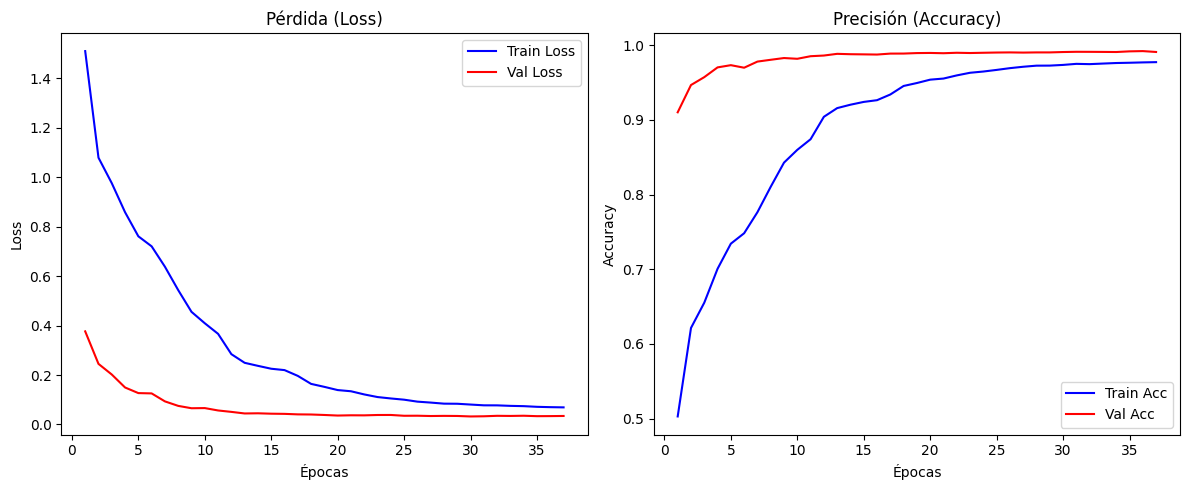

In [22]:
import matplotlib.pyplot as plt

def graficar_entrenamiento(history):
    epochs = range(1, len(history['loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Gráfica de Pérdida (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    plt.title('Pérdida (Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    
    # Gráfica de Precisión (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['acc'], 'b-', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'r-', label='Val Acc')
    plt.title('Precisión (Accuracy)')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Llamada al terminar el entrenamiento
graficar_entrenamiento(cnn_history)

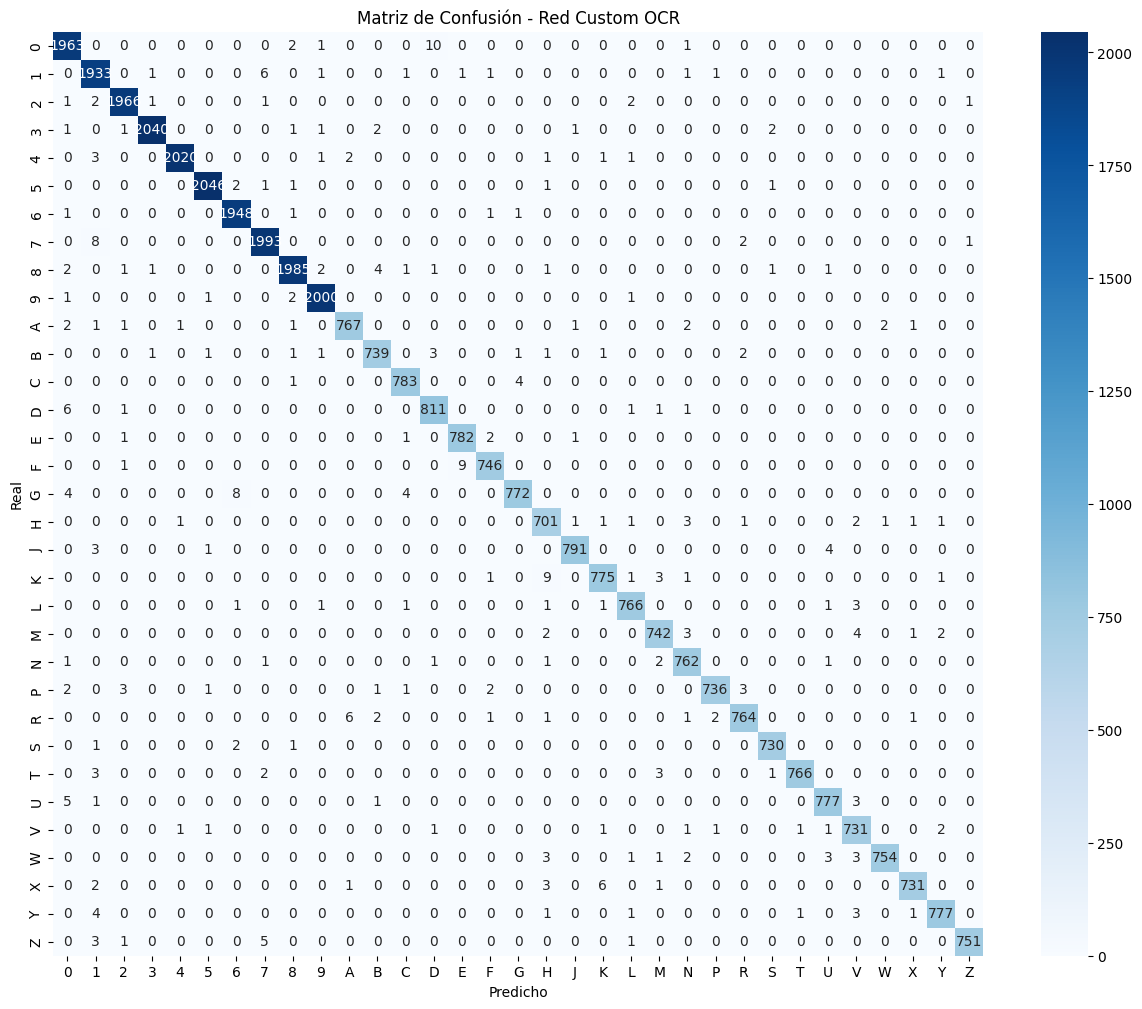


Reporte de Clasificación:


InvalidParameterError: The 'target_names' parameter of classification_report must be an array-like or None. Got '0123456789ABCDEFGHJKLMNPRSTUVWXYZ' instead.

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def generar_reportes_finales(model, loader, classes):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    # 1. Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Matriz de Confusión - Red Custom OCR')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()
    
    # 2. Reporte de Clasificación (Precision, Recall, F1-Score)
    print("\nReporte de Clasificación:")
    print(classification_report(y_true, y_pred, target_names=classes))

alfabeto = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
alfabeto_uso = "0123456789ABCDEFGHJKLMNPRSTUVWXYZ"
# Ejecución (usa tu lista de 33 caracteres extraída del dataset)
generar_reportes_finales(cnn_model, val_loader, alfabeto_uso)

In [11]:
def contar_parametros(modelo):
    # Parámetros totales (incluye los que no se entrenan)
    totales = sum(p.numel() for p in modelo.parameters())
    # Parámetros entrenables (los que realmente se actualizan)
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    
    print(f"Número total de parámetros: {totales:,}")
    print(f"Número de parámetros entrenables: {entrenables:,}")

# Uso con tu red custom
contar_parametros(cnn_model)

Número total de parámetros: 4,305,441
Número de parámetros entrenables: 4,305,441


In [14]:
!pip install torchsummary

In [15]:
from torchsummary import summary

# El segundo argumento es la forma de entrada (C, H, W) 
# En tu caso es (3, 64, 64) porque usas RGB y redimensión a 64x64
summary(cnn_model, (3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             896
       BatchNorm2d-2           [-1, 32, 64, 64]              64
              ReLU-3           [-1, 32, 64, 64]               0
         MaxPool2d-4           [-1, 32, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]          18,496
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
         MaxPool2d-8           [-1, 64, 16, 16]               0
            Conv2d-9          [-1, 128, 16, 16]          73,856
      BatchNorm2d-10          [-1, 128, 16, 16]             256
             ReLU-11          [-1, 128, 16, 16]               0
        MaxPool2d-12            [-1, 128, 8, 8]               0
          Flatten-13                 [-1, 8192]               0
           Linear-14                  [

In [ ]:
print("\nEntrenando CNN Personalizada...")

# Instanciar modelo
cnn_model = CustomOCR_CNN(num_classes=NUM_CLASSES).to(DEVICE)

# Configuración
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Historial
cnn_history = {'loss': [], 'acc': []}

start_time = time.time()

for epoch in range(EPOCHS):
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Barra de progreso
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Forward
        outputs = cnn_model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        # Métricas
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    cnn_history['loss'].append(epoch_loss)
    cnn_history['acc'].append(epoch_acc)
    
    print(f"   Epoch {epoch+1}: Loss={epoch_loss:.4f}, Accuracy={epoch_acc:.4f}")

cnn_train_time = time.time() - start_time
print(f"CNN Entrenamiento completado en {cnn_train_time:.2f} segundos.")

# Guardar modelo CNN
cnn_save_path = os.path.join(PROJECT_DIR, 'custom_cnn_best.pth')
torch.save(cnn_model.state_dict(), cnn_save_path)
print(f"Modelo guardado en: {cnn_save_path}")


Entrenando CNN Personalizada...


Epoch 1/50:   0%|          | 0/2955 [00:00<?, ?it/s]

   Epoch 1: Loss=0.6627, Accuracy=0.7956


Epoch 2/50:   0%|          | 0/2955 [00:00<?, ?it/s]

   Epoch 2: Loss=0.2816, Accuracy=0.9062


...

   Epoch 48: Loss=0.0233, Accuracy=0.9929


Epoch 49/50:   0%|          | 0/2955 [00:00<?, ?it/s]

   Epoch 49: Loss=0.0241, Accuracy=0.9924


Epoch 50/50:   0%|          | 0/2955 [00:00<?, ?it/s]

   Epoch 50: Loss=0.0235, Accuracy=0.9927
CNN Entrenamiento completado en 6724.71 segundos.
Modelo guardado en: ../../models/03_caracteres/custom_cnn_best.pth


In [26]:
print("\nEntrenando CNN Personalizada...")

# Instanciar modelo
cnn_model = CustomOCR_CNN(num_classes=NUM_CLASSES).to(DEVICE)

# Configuración
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Historial
cnn_history = {'loss': [], 'acc': []}

start_time = time.time()

for epoch in range(EPOCHS):
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Barra de progreso
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Forward
        outputs = cnn_model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        # Métricas
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    cnn_history['loss'].append(epoch_loss)
    cnn_history['acc'].append(epoch_acc)
    
    print(f"   Epoch {epoch+1}: Loss={epoch_loss:.4f}, Accuracy={epoch_acc:.4f}")

cnn_train_time = time.time() - start_time
print(f"CNN Entrenamiento completado en {cnn_train_time:.2f} segundos.")

# Guardar modelo CNN
cnn_save_path = os.path.join(PROJECT_DIR, 'custom_cnn_best.pth')
torch.save(cnn_model.state_dict(), cnn_save_path)
print(f"Modelo guardado en: {cnn_save_path}")


Entrenando CNN Personalizada...


Epoch 1/50:   0%|          | 0/2955 [00:00<?, ?it/s]

   Epoch 1: Loss=0.8404, Accuracy=0.7332


Epoch 2/50:   0%|          | 0/2955 [00:00<?, ?it/s]

   Epoch 2: Loss=0.4169, Accuracy=0.8575


...

   Epoch 48: Loss=0.0263, Accuracy=0.9918


Epoch 49/50:   0%|          | 0/2955 [00:00<?, ?it/s]

   Epoch 49: Loss=0.0277, Accuracy=0.9916


Epoch 50/50:   0%|          | 0/2955 [00:00<?, ?it/s]

   Epoch 50: Loss=0.0274, Accuracy=0.9919
CNN Entrenamiento completado en 6844.88 segundos.
Modelo guardado en: ../../models/03_caracteres/custom_cnn_best.pth


In [25]:
# Rutas a los archivos guardados 
run_name_yolo = f"{datetime.now().strftime('%Y%m%d')}_ocr_yolo_v8n"  
rum_name_yolo = f"20260506_ocr_yolo_v8n"
YOLO_WEIGHTS = os.path.join(PROJECT_DIR, run_name_yolo, 'weights', 'best.pt') 
CNN_WEIGHTS = os.path.join(PROJECT_DIR, 'custom_cnn_best_33.pth')

print(f"Cargando YOLO desde: {YOLO_WEIGHTS}")
print(f"Cargando CNN desde: {CNN_WEIGHTS}")

Cargando YOLO desde: ../../models/03_caracteres/20260506_ocr_yolo_v8n/weights/best.pt
Cargando CNN desde: ../../models/03_caracteres/custom_cnn_best_33.pth


In [26]:
# 1. Instanciar la arquitectura 
loaded_cnn = CustomOCR_CNN(num_classes=NUM_CLASSES).to(DEVICE)

# 2. Cargar el diccionario de pesos
try:
    state_dict = torch.load(CNN_WEIGHTS)
    
    # 3. Inyectar los pesos al esqueleto
    loaded_cnn.load_state_dict(state_dict)
    
    # 4. Poner en modo evaluación (Congela Dropout y BatchNorm)
    loaded_cnn.eval()
    
    print("Modelo CNN cargado exitosamente.")
    
    cnn_train_time = 3416.40
except Exception as e:
    print(f"Error cargando CNN: {e}")

Modelo CNN cargado exitosamente.


/tmp/ipykernel_7383/4258484010.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(CNN_WEIGHTS)


In [27]:
def evaluate_model(model, loader, model_type='cnn'):
    model.eval() # Modo evaluación (importante para Dropout/BatchNorm)
    all_preds = []
    all_labels = []
    inference_times = []
    
    print(f"Evaluando {model_type}...")
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader):
            # Preparar inputs según modelo
            if model_type == 'cnn':
                inputs = inputs.to(DEVICE)
            else:
                # YOLO espera rutas de archivos o arrays numpy, pero aquí
                # estamos pasando tensores. Para ser justos en velocidad,
                # usaremos el método .predict() de YOLO en lote si es posible,
                # o convertiremos. Para simplificar, usaremos validación integrada de YOLO arriba
                # y aquí solo mediremos CNN, luego uniremos datos.
                pass 

            if model_type == 'cnn':
                start = time.time()
                outputs = model(inputs)
                end = time.time()
                
                _, predicted = outputs.max(1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
                
                # Tiempo por batch -> Tiempo por imagen
                inference_times.append((end - start) / inputs.size(0))

    if model_type == 'cnn':
        acc = accuracy_score(all_labels, all_preds)
        avg_inference_ms = (sum(inference_times) / len(inference_times)) * 1000
        return acc, avg_inference_ms




In [29]:
# Cargando el modelo de yolo
run_name = f"20260506_ocr_yolo_v8n_33"

# Cargar el MEJOR modelo resultante del entrenamiento anterior
model_yolov8n_baseline_tl = os.path.join(PROJECT_DIR, run_name, 'weights', 'best.pt')
model_yolo = YOLO(model_yolov8n_baseline_tl)

yolo_train_time = 0.714*3600000

Evaluando cnn...


  0%|          | 0/589 [00:00<?, ?it/s]

Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11854MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,477,153 parameters, 0 gradients, 3.3 GFLOPs
train: /home/roberto/moca_proyecto/datasets/03_caracteres/train... found 150677 images in 33 classes ✅ 
val: /home/roberto/moca_proyecto/datasets/03_caracteres/val... found 37685 images in 33 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 129.3±52.9 MB/s, size: 1.8 KB)
val: Scanning /home/roberto/moca_proyecto/datasets/03_caracteres/val... 37685 images, 0 corrupt: 100% ━━━━━━━━━━━━ 37685/37685 96.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2356/2356 385.3it/s 6.1s<0.0s
                   all      0.974          1
Speed: 0.0ms preprocess, 0.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /home/roberto/moca_proyecto/notebooks/03_caracteres/runs/classify/val5

TABLA DE RESULTADOS:


,Modelo,Accuracy (Top-1),Tiempo Entrenamiento (s),Velocidad Inferencia (ms/img)
0,YOLOv8n-CLS,0.974075,2570400.0,0.137401
1,Custom CNN,0.991455,3416.4,0.011631


/tmp/ipykernel_7383/3746691427.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Modelo', y='Accuracy (Top-1)', ax=ax[0], palette='viridis')
/tmp/ipykernel_7383/3746691427.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Modelo', y='Velocidad Inferencia (ms/img)', ax=ax[1], palette='rocket')
/tmp/ipykernel_7383/3746691427.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Modelo', y='Tiempo Entrenamiento (s)', ax=ax[2], palette='magma')


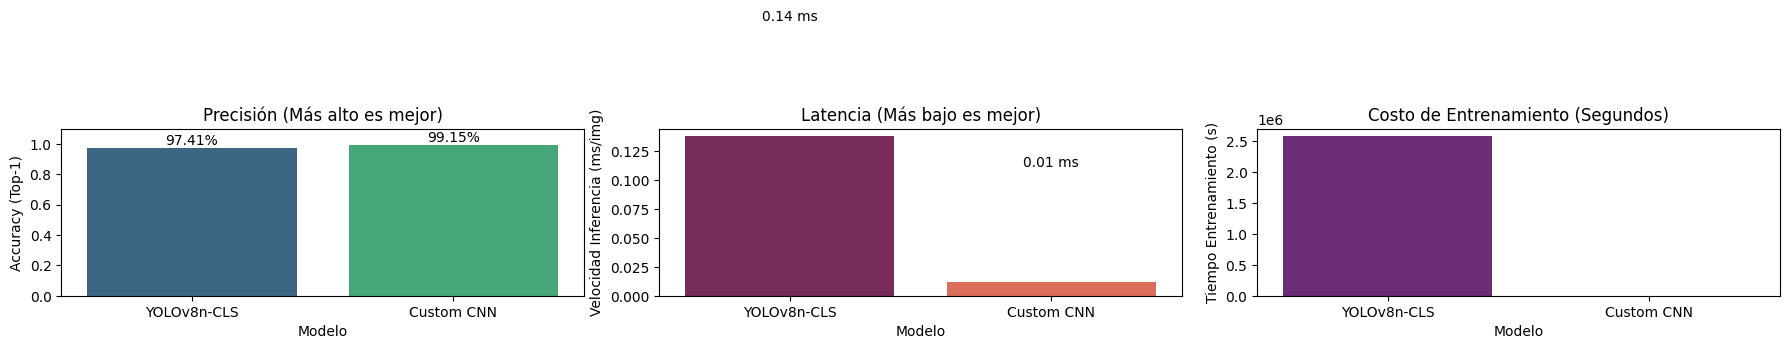

In [30]:
# 1. Evaluar CNN
# cnn_acc, cnn_speed = evaluate_model(cnn_model, val_loader, 'cnn')
cnn_acc, cnn_speed = evaluate_model(loaded_cnn, val_loader, 'cnn')

# 2. Obtener métricas de YOLO (del objeto results)
# YOLO calcula esto automáticamente al entrenar
yolo_metrics = model_yolo.val()
yolo_acc = yolo_metrics.top1
yolo_speed = yolo_metrics.speed['inference'] # ms per image

# --- REPORTE FINAL ---
comparison_data = {
    'Modelo': ['YOLOv8n-CLS', 'Custom CNN'],
    'Accuracy (Top-1)': [yolo_acc, cnn_acc],
    'Tiempo Entrenamiento (s)': [yolo_train_time, cnn_train_time],
    'Velocidad Inferencia (ms/img)': [yolo_speed, cnn_speed]
}

df_results = pd.DataFrame(comparison_data)

print("\nTABLA DE RESULTADOS:")
display(df_results)

# Graficar
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: Accuracy
sns.barplot(data=df_results, x='Modelo', y='Accuracy (Top-1)', ax=ax[0], palette='viridis')
ax[0].set_title('Precisión (Más alto es mejor)')
ax[0].set_ylim(0, 1.1)
for i, v in enumerate(df_results['Accuracy (Top-1)']):
    ax[0].text(i, v + 0.02, f"{v:.2%}", ha='center')

# Gráfica 2: Velocidad
sns.barplot(data=df_results, x='Modelo', y='Velocidad Inferencia (ms/img)', ax=ax[1], palette='rocket')
ax[1].set_title('Latencia (Más bajo es mejor)')
for i, v in enumerate(df_results['Velocidad Inferencia (ms/img)']):
    ax[1].text(i, v + 0.1, f"{v:.2f} ms", ha='center')

# Gráfica 3: Tiempo Entrenamiento
sns.barplot(data=df_results, x='Modelo', y='Tiempo Entrenamiento (s)', ax=ax[2], palette='magma')
ax[2].set_title('Costo de Entrenamiento (Segundos)')

plt.tight_layout()
plt.show()

In [33]:
model_yolo.info()

YOLOv8n-cls summary (fused): 30 layers, 1,477,153 parameters, 0 gradients, 3.3 GFLOPs


(30, 1477153, 0, 3.3224704)

In [31]:
print("\n--- INICIANDO EVALUACIÓN COMPARATIVA ---")

# 1. Evaluar CNN Propia
# Pasamos el objeto cargado 'loaded_cnn' y el string 'cnn'
acc_cnn, lat_cnn = evaluate_model(loaded_cnn, val_loader, model_type='cnn')

print(f"\nResultados CNN Personalizada:")
print(f"   • Accuracy: {acc_cnn:.4f}")
print(f"   • Latencia: {lat_cnn:.4f} ms")

# 2. Evaluar YOLOv8
# YOLO tiene su propio método .val() que es más robusto para métricas internas,
# pero si quieres usar tu función 'evaluate_model' para medir tiempo en igualdad de condiciones:

# Opción A: Usar método nativo de YOLO (Recomendado para Accuracy)
metrics_yolo = model_yolo.val(data=DATASET_DIR, verbose=False)
acc_yolo = metrics_yolo.top1
# La velocidad la sacamos del objeto metrics
lat_yolo = metrics_yolo.speed['inference'] 

print(f"\nResultados YOLOv8n:")
print(f"   • Accuracy: {acc_yolo:.4f}")
print(f"   • Latencia: {lat_yolo:.4f} ms")

# --- COMPARACIÓN FINAL ---
print("\nVERDICTO FINAL:")
if lat_cnn < lat_yolo:
    diff = lat_yolo / lat_cnn
    print(f"Tu CNN es {diff:.1f}x veces más rápida que YOLO.")
else:
    print(f"YOLO es más rápido.")

if acc_cnn > acc_yolo:
    print(f"Tu CNN es más precisa.")
else:
    diff_acc = (acc_yolo - acc_cnn) * 100
    print(f"Tu CNN es un {diff_acc:.2f}% menos precisa (Trade-off aceptable).")


--- INICIANDO EVALUACIÓN COMPARATIVA ---
Evaluando cnn...


  0%|          | 0/589 [00:00<?, ?it/s]


Resultados CNN Personalizada:
   • Accuracy: 0.9911
   • Latencia: 0.0114 ms
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11854MiB)
train: /home/roberto/moca_proyecto/datasets/03_caracteres/train... found 150677 images in 33 classes ✅ 
val: /home/roberto/moca_proyecto/datasets/03_caracteres/val... found 37685 images in 33 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 132.4±61.5 MB/s, size: 1.8 KB)
val: Scanning /home/roberto/moca_proyecto/datasets/03_caracteres/val... 37685 images, 0 corrupt: 100% ━━━━━━━━━━━━ 37685/37685 84.1Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2356/2356 390.3it/s 6.0s0.1s
                   all      0.974          1
Speed: 0.0ms preprocess, 0.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /home/roberto/moca_proyecto/notebooks/03_caracteres/runs/classify/val6

Resultados YOLOv8n:
   • Accuracy: 0.9741
   • Latencia: 0.1359 ms

VERD

In [8]:
print("\ROUND 1: Entrenando YOLOv8 Nano (Classifier) para 30,000 imágenes...")

# Nombre del experimento YOLO
run_name_yolo = f"{datetime.now().strftime('%Y%m%d')}_ocr_yolo_v8n_30k"

# Cargar modelo
model_yolo = YOLO('yolov8n-cls.pt')

# Entrenar
start_time = time.time()
results_yolo = model_yolo.train(
    data=DATASET_DIR,
    project=PROJECT_DIR,
    name=run_name_yolo,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    pretrained=True,
    device=0 if torch.cuda.is_available() else 'cpu',
    verbose=True
)
yolo_train_time = time.time() - start_time

print(f"YOLO entrenamiento completado en {yolo_train_time:.2f} segundos.")

\ROUND 1: Entrenando YOLOv8 Nano (Classifier) para 30,000 imágenes...
New https://pypi.org/project/ultralytics/8.3.234 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11852MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/03_caracteres, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, 

In [9]:
class CustomOCR_CNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomOCR_CNN, self).__init__()
        
        # Bloque Convolucional 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Salida: 32x32
        )
        
        # Bloque Convolucional 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Salida: 16x16
        )
        
        # Bloque Convolucional 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Salida: 8x8
        )
        
        # Clasificador (Fully Connected)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512), # Ajustar según IMG_SIZE (64 -> 8x8 feature map)
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

print("Arquitectura CNN definida.")

Arquitectura CNN definida.


In [10]:
print("\nROUND 2: Entrenando CNN Personalizada...")

# Instanciar modelo
cnn_model = CustomOCR_CNN(num_classes=NUM_CLASSES).to(DEVICE)

# Configuración
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Historial
cnn_history = {'loss': [], 'acc': []}

start_time = time.time()

for epoch in range(EPOCHS):
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Barra de progreso
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Forward
        outputs = cnn_model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        # Métricas
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    cnn_history['loss'].append(epoch_loss)
    cnn_history['acc'].append(epoch_acc)
    
    print(f"   Epoch {epoch+1}: Loss={epoch_loss:.4f}, Accuracy={epoch_acc:.4f}")

cnn_train_time = time.time() - start_time
print(f"CNN Entrenamiento completado en {cnn_train_time:.2f} segundos.")

# Guardar modelo CNN
cnn_save_path = os.path.join(PROJECT_DIR, 'custom_cnn_best.pth')
torch.save(cnn_model.state_dict(), cnn_save_path)
print(f"Modelo guardado en: {cnn_save_path}")


ROUND 2: Entrenando CNN Personalizada...


Epoch 1/20:   0%|          | 0/2635 [00:00<?, ?it/s]

   Epoch 1: Loss=2.5670, Accuracy=0.2187


Epoch 2/20:   0%|          | 0/2635 [00:00<?, ?it/s]

   Epoch 2: Loss=2.2446, Accuracy=0.2844


...

   Epoch 18: Loss=0.5979, Accuracy=0.7959


Epoch 19/20:   0%|          | 0/2635 [00:00<?, ?it/s]

   Epoch 19: Loss=0.5694, Accuracy=0.8055


Epoch 20/20:   0%|          | 0/2635 [00:00<?, ?it/s]

   Epoch 20: Loss=0.5484, Accuracy=0.8130
CNN Entrenamiento completado en 1159.69 segundos.
Modelo guardado en: ../../models/03_caracteres/custom_cnn_best.pth


In [17]:
def evaluate_model(model, loader, model_type='cnn'):
    model.eval()
    all_preds = []
    all_labels = []
    inference_times = []
    
    print(f"Evaluando {model_type} (Con Sincronización CUDA)...")
    
    # Calentamiento (Warm-up)
    # Es vital hacer pasar unos datos "de mentira" para despertar a la GPU
    if torch.cuda.is_available():
        dummy_input = torch.randn(1, 3, 64, 64).to(DEVICE)
        for _ in range(10):
            _ = model(dummy_input)
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader):
            if model_type == 'cnn':
                inputs = inputs.to(DEVICE)
            
            # --- MEDICIÓN PRECISA ---
            if torch.cuda.is_available():
                torch.cuda.synchronize() # Esperar a que la GPU esté libre
            
            start = time.time()
            
            if model_type == 'cnn':
                outputs = model(inputs)
            else:
                # Lógica para YOLO si fuera necesario
                pass
                
            if torch.cuda.is_available():
                torch.cuda.synchronize() # <--- CLAVE: Esperar a que termine el cálculo
            
            end = time.time()
            # ------------------------

            # Solo medimos el tiempo de inferencia pura, no el post-proceso
            inference_times.append((end - start) / inputs.size(0))
            
            # Post-proceso (fuera del cronómetro)
            if model_type == 'cnn':
                _, predicted = outputs.max(1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())

    if model_type == 'cnn':
        acc = accuracy_score(all_labels, all_preds)
        # Promedio de latencia
        avg_inference_ms = (sum(inference_times) / len(inference_times)) * 1000
        return acc, avg_inference_ms

# 1. Evaluar CNN
cnn_acc, cnn_speed = evaluate_model(cnn_model, val_loader, 'cnn')

# 2. Obtener métricas de YOLO (del objeto results)
# YOLO calcula esto automáticamente al entrenar
yolo_metrics = model_yolo.val()
yolo_acc = yolo_metrics.top1
yolo_speed = yolo_metrics.speed['inference'] # ms per image

# --- REPORTE FINAL ---
comparison_data = {
    'Modelo': ['YOLOv8n-CLS', 'Custom CNN'],
    'Accuracy (Top-1)': [yolo_acc, cnn_acc],
    'Tiempo Entrenamiento (s)': [yolo_train_time, cnn_train_time],
    'Velocidad Inferencia (ms/img)': [yolo_speed, cnn_speed]
}

df_results = pd.DataFrame(comparison_data)

print("\nTABLA DE RESULTADOS:")
display(df_results)

# Graficar
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: Accuracy
sns.barplot(data=df_results, x='Modelo', y='Accuracy (Top-1)', ax=ax[0], palette='viridis', hue='Modelo', legend=False)
ax[0].set_title('Precisión (Más alto es mejor)')
ax[0].set_ylim(0, 1.1)
for i, v in enumerate(df_results['Accuracy (Top-1)']):
    ax[0].text(i, v + 0.02, f"{v:.2%}", ha='center')

# Gráfica 2: Velocidad
sns.barplot(data=df_results, x='Modelo', y='Velocidad Inferencia (ms/img)', ax=ax[1], palette='rocket')
ax[1].set_title('Latencia (Más bajo es mejor)')
for i, v in enumerate(df_results['Velocidad Inferencia (ms/img)']):
    ax[1].text(i, v + 0.1, f"{v:.2f} ms", ha='center')

# Gráfica 3: Tiempo Entrenamiento
sns.barplot(data=df_results, x='Modelo', y='Tiempo Entrenamiento (s)', ax=ax[2], palette='magma')
ax[2].set_title('Costo de Entrenamiento (Segundos)')

plt.tight_layout()
plt.show()

NameError: name 'cnn_model' is not defined